In [ ]:
#importar librerias
import pandas as pd
import seaborn as sns
from IPython.display import display
import matplotlib.pyplot as plt  

In [34]:
# Cargar el dataset
df = pd.read_csv(r"C:\Users\LENOVO\Downloads\hotel_bookings.csv.zip")

In [ ]:
# Definir dimension de dataset
filas, columnas = df.shape
print(f"Cantidad de filas: {filas}")
print(f"Cantidad de columnas: {columnas}")

Cantidad de filas: 119390
Cantidad de columnas: 32


In [8]:
# Ver todas las columnas
print("Columnas del dataset:\n")
print(df.columns)

Columnas del dataset:

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


In [9]:
# Subset primeras 16 columnas
primeras_16 = df.iloc[:, :16]

print("===== PRIMERAS 16 COLUMNAS =====\n")
print(primeras_16.info())

===== PRIMERAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   hotel                      119390 non-null  object 
 1   is_canceled                119390 non-null  int64  
 2   lead_time                  119390 non-null  int64  
 3   arrival_date_year          119390 non-null  int64  
 4   arrival_date_month         119390 non-null  object 
 5   arrival_date_week_number   119390 non-null  int64  
 6   arrival_date_day_of_month  119390 non-null  int64  
 7   stays_in_weekend_nights    119390 non-null  int64  
 8   stays_in_week_nights       119390 non-null  int64  
 9   adults                     119390 non-null  int64  
 10  children                   119386 non-null  float64
 11  babies                     119390 non-null  int64  
 12  meal                       119390 non-null  object 


In [10]:
# Subset últimas 16 columnas
ultimas_16 = df.iloc[:, 16:]

print("===== ÚLTIMAS 16 COLUMNAS =====\n")
print(ultimas_16.info())

===== ÚLTIMAS 16 COLUMNAS =====

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_repeated_guest               119390 non-null  int64  
 1   previous_cancellations          119390 non-null  int64  
 2   previous_bookings_not_canceled  119390 non-null  int64  
 3   reserved_room_type              119390 non-null  object 
 4   assigned_room_type              119390 non-null  object 
 5   booking_changes                 119390 non-null  int64  
 6   deposit_type                    119390 non-null  object 
 7   agent                           103050 non-null  float64
 8   company                         6797 non-null    float64
 9   days_in_waiting_list            119390 non-null  int64  
 10  customer_type                   119390 non-null  object 
 11  adr                             119390 non-nu

In [11]:
#analisis de nulos primeras 16 columnas 
primeras_16 = df.iloc[:, :16]

print("Valores nulos por columna (primeras 16):\n")
print(primeras_16.isnull().sum())
total_nulos_primeras = primeras_16.isnull().sum().sum()
print("\nTotal de valores nulos en las primeras 16 columnas:", total_nulos_primeras)

Valores nulos por columna (primeras 16):

hotel                          0
is_canceled                    0
lead_time                      0
arrival_date_year              0
arrival_date_month             0
arrival_date_week_number       0
arrival_date_day_of_month      0
stays_in_weekend_nights        0
stays_in_week_nights           0
adults                         0
children                       4
babies                         0
meal                           0
country                      488
market_segment                 0
distribution_channel           0
dtype: int64

Total de valores nulos en las primeras 16 columnas: 492


In [12]:
#analisis de nulos ultimas 16 columnas 

ultimas_16 = df.iloc[:, -16:]

print("\nValores nulos por columna (últimas 16):\n")
print(ultimas_16.isnull().sum())
total_nulos_ultimas = ultimas_16.isnull().sum().sum()
print("\nTotal de valores nulos en las últimas 16 columnas:", total_nulos_ultimas)



Valores nulos por columna (últimas 16):

is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company                           112593
days_in_waiting_list                   0
customer_type                          0
adr                                    0
required_car_parking_spaces            0
total_of_special_requests              0
reservation_status                     0
reservation_status_date                0
dtype: int64

Total de valores nulos en las últimas 16 columnas: 128933


In [13]:
#se averigua la mediana para reemplazar los valores nulos en esa columna 
mediana_children = df['children'].median()
print("La mediana de children es:", mediana_children)

La mediana de children es: 0.0


In [14]:
# children: reemplazar nulos por 0 (si no hay niños)
df['children'] = df['children'].fillna(0)

In [26]:
#reemplazamos los nulos de la columna country por desconocido 'Unknown'
df['country'] = df['country'].fillna('Unknown')

In [27]:
#reemplazamos los nulos de agent por 0 ya que es numerica la columna 
df['agent'] = df['agent'].fillna(0)


In [32]:
#se reemplazan los nan de la columna company por 0, ya que es de tipo float (con comapañia vs sin compañia)
df['company'] = df['company'].fillna(0)


In [34]:
total_nulos_dataset = total_nulos_primeras + total_nulos_ultimas
print("\nTotal de valores nulos en todo el dataset:", total_nulos_dataset)


Total de valores nulos en todo el dataset: 0


In [18]:
# Filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 31994


In [19]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103886,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398555,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [21]:
# Se utiliza la funcion round para visualizar mejor los datos
df.describe().round()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,119390.0,103050.0,6797.0,119390.0,119390.0,119390.0,119390.0
mean,0.0,104.0,2016.0,27.0,16.0,1.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,87.0,189.0,2.0,102.0,0.0,1.0
std,0.0,107.0,1.0,14.0,9.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,111.0,132.0,18.0,51.0,0.0,1.0
min,0.0,0.0,2015.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,0.0,-6.0,0.0,0.0
25%,0.0,18.0,2016.0,16.0,8.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,62.0,0.0,69.0,0.0,0.0
50%,0.0,69.0,2016.0,28.0,16.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,14.0,179.0,0.0,95.0,0.0,0.0
75%,1.0,160.0,2017.0,38.0,23.0,2.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,229.0,270.0,0.0,126.0,0.0,1.0
max,1.0,737.0,2017.0,53.0,31.0,19.0,50.0,55.0,10.0,10.0,1.0,26.0,72.0,21.0,535.0,543.0,391.0,5400.0,8.0,5.0


In [ ]:
# Se realiza un Histograma para la columna que queramos 
from seaborn import distplot
distplot(wine_quality.quality, hist=False)

In [15]:
# Columnas categóricas primeras 10
cat_cols = df.select_dtypes(include=['object']).columns

# Tomar solo las primeras 10 columnas (o menos si hay menos de 10)
primeras_10 = cat_cols[:10]

# Mostrar cada columna y su distribución de valores
for col in primeras_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())




Columna: hotel


hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


Columna: arrival_date_month


arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64


Columna: meal


...

assigned_room_type
A    74053
D    25322
E     7806
F     3751
G     2553
C     2375
B     2163
H      712
I      363
K      279
P       12
L        1
Name: count, dtype: int64


Columna: deposit_type


deposit_type
No Deposit    104641
Non Refund     14587
Refundable       162
Name: count, dtype: int64


Columna: customer_type


customer_type
Transient          89613
Transient-Party    25124
Contract            4076
Group                577
Name: count, dtype: int64

In [16]:
# Columnas categóricas 1
cat_cols = df.select_dtypes(include=['object']).columns

# Excluir reservation_status_date
cat_cols_sin_fecha = [col for col in cat_cols if col != 'reservation_status_date']

# Tomar las columnas de la 11 a la 20 (máximo 10)
siguientes_10 = cat_cols_sin_fecha[10:20]

# Mostrar cada columna y su distribución de valores
for col in siguientes_10:
    print(f"\nColumna: {col}")
    display(df[col].value_counts())



Columna: reservation_status


reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

In [38]:
# Convertir a datetime 1
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Conteo por año
print("\nConteo por año:")
display(df['reservation_status_date'].dt.year.value_counts().sort_index())

# Conteo por mes
print("\nConteo por mes:")
display(df['reservation_status_date'].dt.month.value_counts().sort_index())

# Conteo por día de la semana
print("\nConteo por día de la semana (0=Lunes, 6=Domingo):")
display(df['reservation_status_date'].dt.dayofweek.value_counts().sort_index())



Conteo por año:


reservation_status_date
2014      181
2015    24929
2016    57797
2017    36483
Name: count, dtype: int64


Conteo por mes:


reservation_status_date
1     10681
2      9498
3     10230
4      9999
5     10304
6      9278
7     12106
8     11249
9      9403
10    11143
11     8099
12     7400
Name: count, dtype: int64


Conteo por día de la semana (0=Lunes, 6=Domingo):


reservation_status_date
0    18692
1    16731
2    17943
3    18141
4    18471
5    12924
6    16488
Name: count, dtype: int64

In [39]:
# Columnas numéricas 20
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Diccionario para renombrar las estadísticas
nombres_es = {
    'count': 'Cantidad',
    'mean': 'Media',
    'std': 'Desviación estándar',
    'min': 'Mínimo',
    '25%': '25%',
    '50%': 'Mediana',
    '75%': '75%',
    'max': 'Máximo'
}

# Iterar sobre cada columna numérica
for col in num_cols:
    print(f"\n=== Columna: {col} ===")
    stats = df[col].describe().to_frame().T  # Convertir a DataFrame y transponer
    stats.rename(columns=nombres_es, inplace=True)  # Renombrar columnas
    display(stats)


=== Columna: is_canceled ===


,Cantidad,Media,Desviación estándar,Mínimo,25%,Mediana,75%,Máximo
is_canceled,119390.0,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0



=== Columna: lead_time ===


,Cantidad,Media,Desviación estándar,Mínimo,25%,Mediana,75%,Máximo
lead_time,119390.0,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0



=== Columna: arrival_date_year ===


...

,Cantidad,Media,Desviación estándar,Mínimo,25%,Mediana,75%,Máximo
adr,119390.0,101.831122,50.53579,-6.38,69.29,94.575,126.0,5400.0



=== Columna: required_car_parking_spaces ===


,Cantidad,Media,Desviación estándar,Mínimo,25%,Mediana,75%,Máximo
required_car_parking_spaces,119390.0,0.062518,0.245291,0.0,0.0,0.0,0.0,8.0



=== Columna: total_of_special_requests ===


,Cantidad,Media,Desviación estándar,Mínimo,25%,Mediana,75%,Máximo
total_of_special_requests,119390.0,0.571363,0.792798,0.0,0.0,0.0,1.0,5.0


In [40]:
# Año mínimo y máximo
print("Rango de años:", df['arrival_date_year'].min(), "-", df['arrival_date_year'].max())

# Meses distintos
print("Meses presentes:", df['arrival_date_month'].unique())


Rango de años: 2015 - 2017
Meses presentes: ['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']


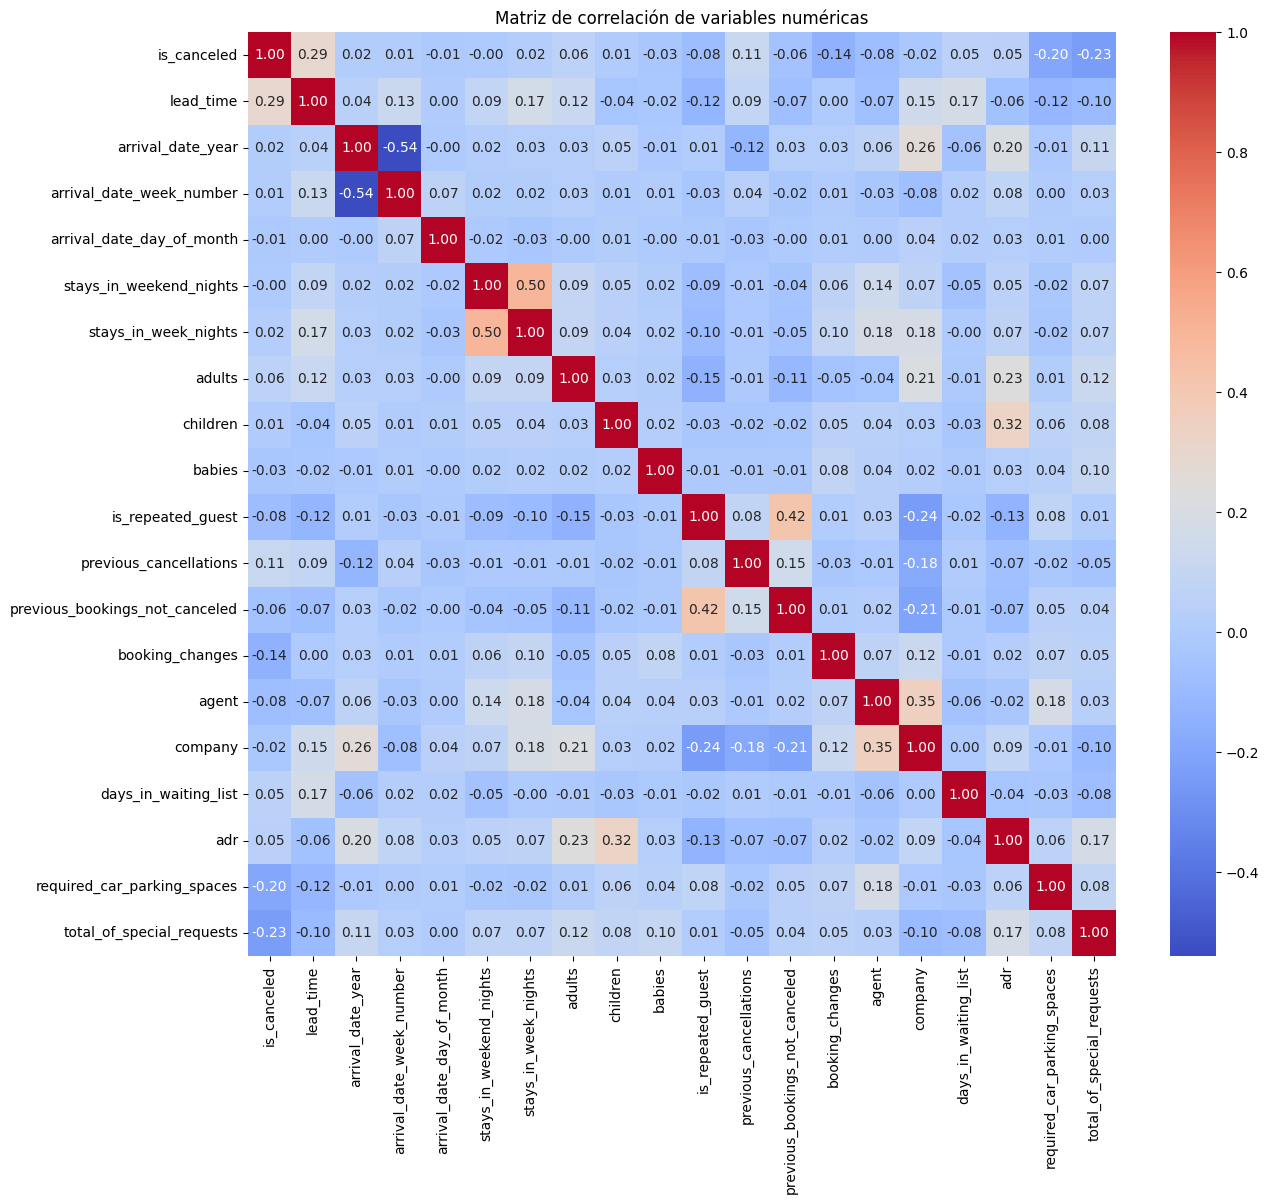

In [38]:
# Seleccionamos solo las columnas numéricas automáticamente
numeric_df = df.select_dtypes(include='number')

# Matriz de correlación
corr_matrix = numeric_df.corr()

# Mapa de calor
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de correlación de variables numéricas')
plt.show()

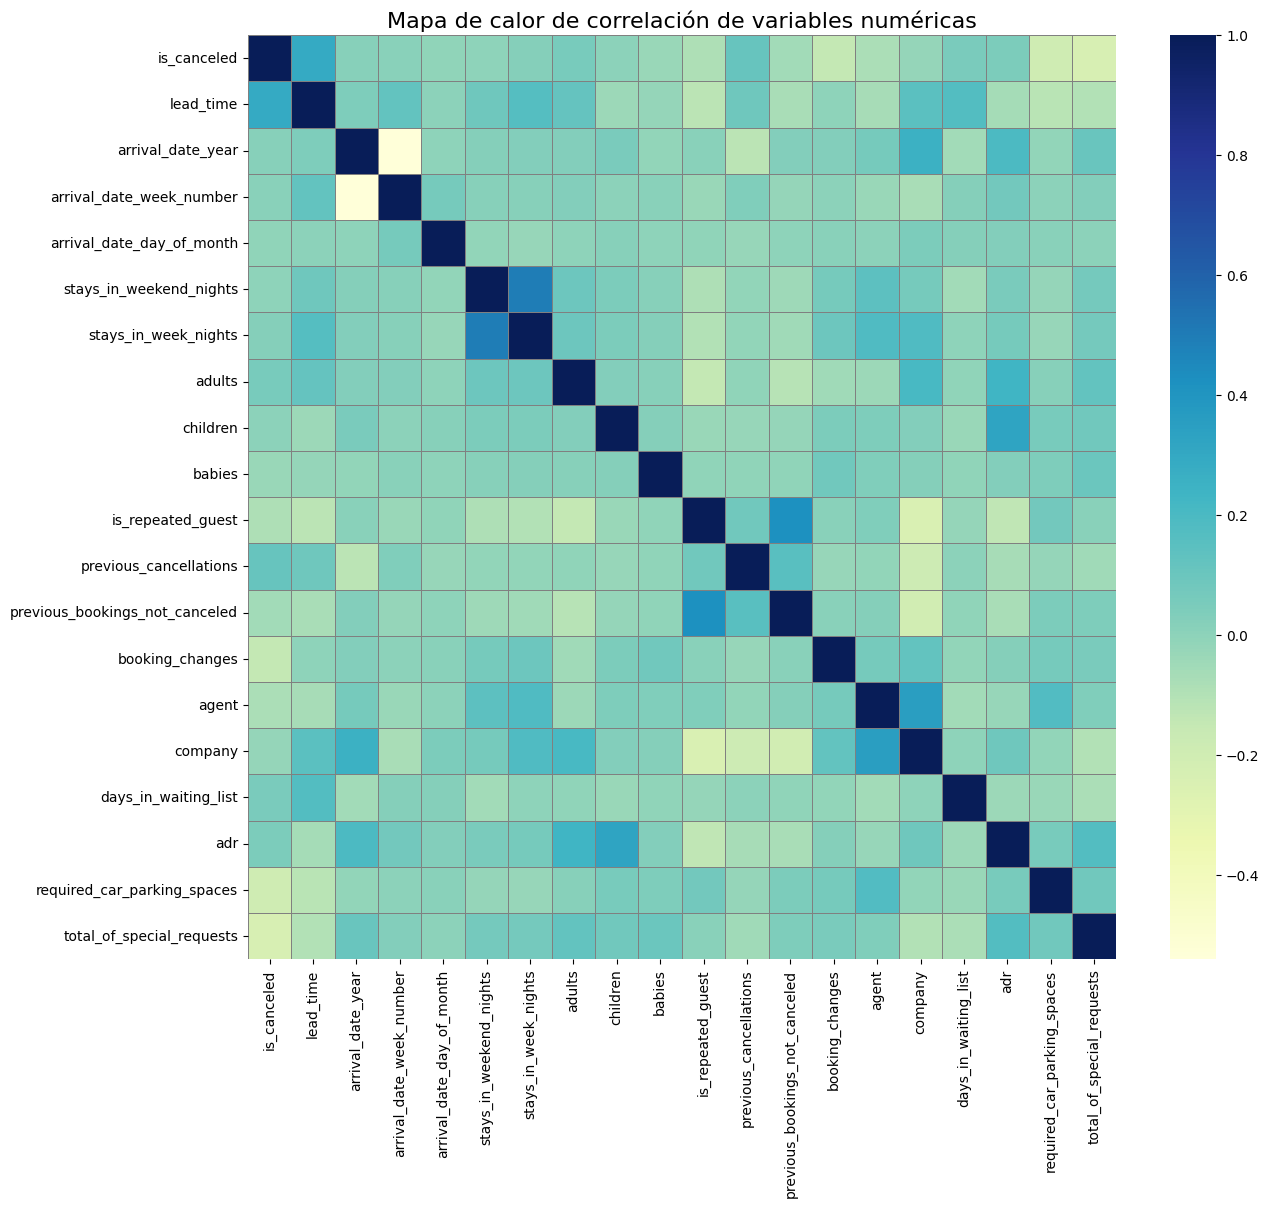

In [40]:
# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include='number')

# Calcular matriz de correlación
corr_matrix = numeric_df.corr()

# Dibujar mapa de calor más visual
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='YlGnBu', linewidths=0.5, linecolor='gray')
plt.title('Mapa de calor de correlación de variables numéricas', fontsize=16)
plt.show()